In [ ]:
!pip install imbalanced-learn -q

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df=pd.read_csv("loan_prediction.csv")

In [ ]:
df.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
df.shape

(614, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 67.2+ KB


In [ ]:
df.columns

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [ ]:
df.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
df.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
#Check loan status
df["Loan_Status"].value_counts()

,count
Loan_Status,
Y,422
N,192


In [ ]:
#Percentage
df["Loan_Status"].value_counts(normalize=True) * 100

,proportion
Loan_Status,
Y,68.729642
N,31.270358


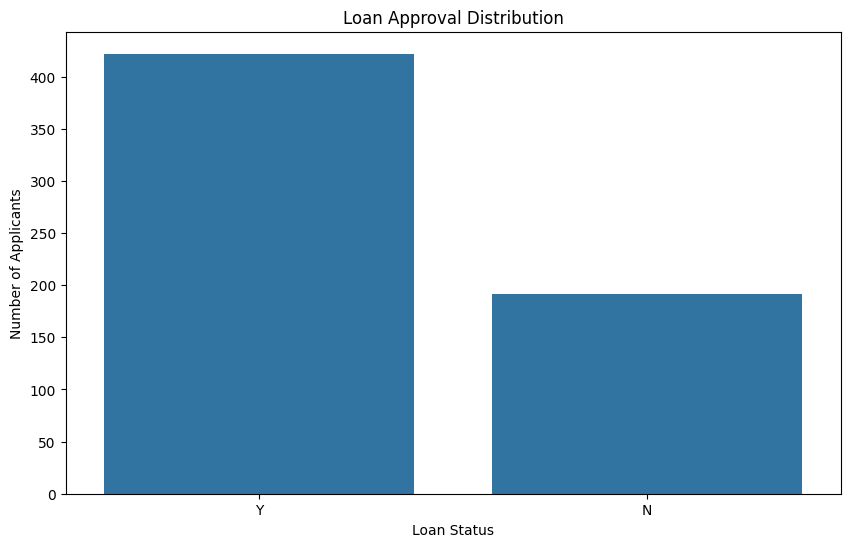

In [ ]:
#Visualization
plt.figure(figsize=(10,6))

sns.countplot(data=df, x="Loan_Status")

plt.title("Loan Approval Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.show()

In [ ]:
# Reload the dataset to restore df as a DataFrame
df = pd.read_csv("loan_prediction.csv")

# Convert Target Variable safely
df["Loan_Status"] = df["Loan_Status"].map({
    "Y": 1,
    "N": 0
})
df["Loan_Status"].value_counts()

,count
Loan_Status,
1,422
0,192


In [ ]:
#Separate Features and Target
X = df.drop(columns=["Loan_Status", "Loan_ID"])

y = df["Loan_Status"]

In [ ]:
X.head()

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area
0,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban


In [ ]:
#Identify Numerical and Categorical Columns
numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_features = X.select_dtypes(
    include=["object"]
).columns

print("Numerical Features:")
print(list(numeric_features))

print("\nCategorical Features:")
print(list(categorical_features))

Numerical Features:
['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

Categorical Features:
['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area']


In [ ]:
#Train / Validation / Test Split
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    stratify=y,
    random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (429, 11)
Validation: (92, 11)
Testing: (93, 11)


In [ ]:
#Data Preprocessing
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)
categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(
            handle_unknown="ignore",
            drop="first"
        ))
    ]
)
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [ ]:
#Handle Class Imbalance
class_weight="balanced"

In [ ]:
#Logistic Regression
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ]
)


In [ ]:
#Train
logistic_model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object'))])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [ ]:
#Prediction
y_pred_lr = logistic_model.predict(X_test)

In [ ]:
#Probability
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

In [ ]:
#Evaluate Logistic Regression
print("Logistic Regression")
print("----------------------------")

print("Precision:",
      precision_score(y_test, y_pred_lr))

print("Recall:",
      recall_score(y_test, y_pred_lr))

print("F1 Score:",
      f1_score(y_test, y_pred_lr))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_lr))

Logistic Regression
----------------------------
Precision: 0.864406779661017
Recall: 0.796875
F1 Score: 0.8292682926829268
ROC-AUC: 0.8335129310344828


In [ ]:
#Classification report
print(classification_report(
    y_test,
    y_pred_lr
))

              precision    recall  f1-score   support

           0       0.62      0.72      0.67        29
           1       0.86      0.80      0.83        64

    accuracy                           0.77        93
   macro avg       0.74      0.76      0.75        93
weighted avg       0.79      0.77      0.78        93



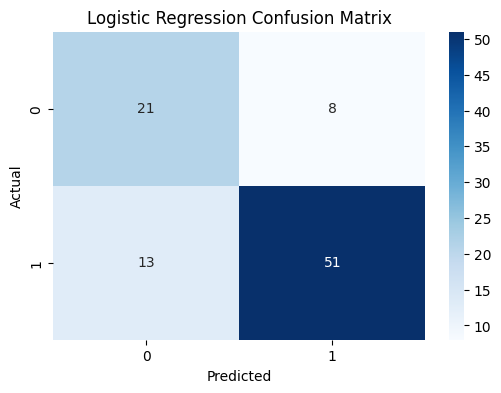

In [ ]:
#Confusion Matrix
cm = confusion_matrix(
    y_test,
    y_pred_lr
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
#Random Forest
rf_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            class_weight="balanced",
            random_state=42,
            max_depth=8,
            min_samples_split=5
        ))
    ]
)

In [ ]:
#Train
rf_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'Property_Area'],
      dtype='object'))])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=8,
                                        min_samples_split=5, n_estimators=300,
                                        random_state=42))])

In [ ]:
#Prediction
y_pred_rf = rf_model.predict(X_test)

In [ ]:
#Probability
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

In [ ]:
#Evaluate Random Forest
print("Random Forest")
print("----------------------------")

print("Precision:",
      precision_score(y_test, y_pred_rf))

print("Recall:",
      recall_score(y_test, y_pred_rf))

print("F1 Score:",
      f1_score(y_test, y_pred_rf))

print("ROC-AUC:",
      roc_auc_score(y_test, y_prob_rf))

Random Forest
----------------------------
Precision: 0.8484848484848485
Recall: 0.875
F1 Score: 0.8615384615384616
ROC-AUC: 0.8248922413793103


In [ ]:
#Classification report
print(classification_report(
    y_test,
    y_pred_rf
))

              precision    recall  f1-score   support

           0       0.70      0.66      0.68        29
           1       0.85      0.88      0.86        64

    accuracy                           0.81        93
   macro avg       0.78      0.77      0.77        93
weighted avg       0.80      0.81      0.80        93



In [ ]:
#Compare Models
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],

    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_rf)
    ],

    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_rf)
    ],

    "F1 Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_rf)
    ],

    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

results

,Model,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.864407,0.796875,0.829268,0.833513
1,Random Forest,0.848485,0.875000,0.861538,0.824892


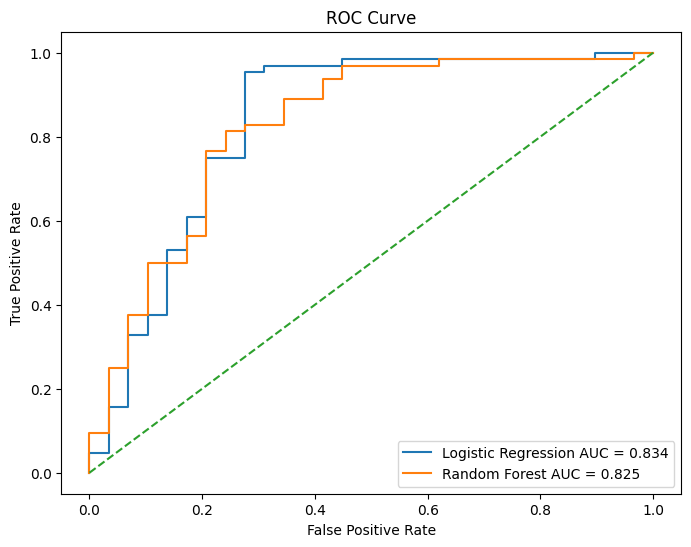

In [ ]:
#ROC Curve
fpr_lr, tpr_lr, _ = roc_curve(
    y_test,
    y_prob_lr
)

fpr_rf, tpr_rf, _ = roc_curve(
    y_test,
    y_prob_rf
)

plt.figure(figsize=(8,6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression AUC = {roc_auc_score(y_test, y_prob_lr):.3f}"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest AUC = {roc_auc_score(y_test, y_prob_rf):.3f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

In [ ]:
#Threshold Analysis
thresholds = np.arange(
    0.20,
    0.81,
    0.05
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        y_prob_rf >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,Threshold,Precision,Recall,F1
0,0.20,0.750000,0.984375,0.851351
1,0.25,0.775000,0.968750,0.861111
2,0.30,0.826667,0.968750,0.892086
3,0.35,0.821918,0.937500,0.875912
4,0.40,0.830986,0.921875,0.874074
5,0.45,0.850746,0.890625,0.870229
6,0.50,0.848485,0.875000,0.861538
7,0.55,0.881356,0.812500,0.845528
8,0.60,0.866667,0.609375,0.715596
9,0.65,0.914286,0.500000,0.646465


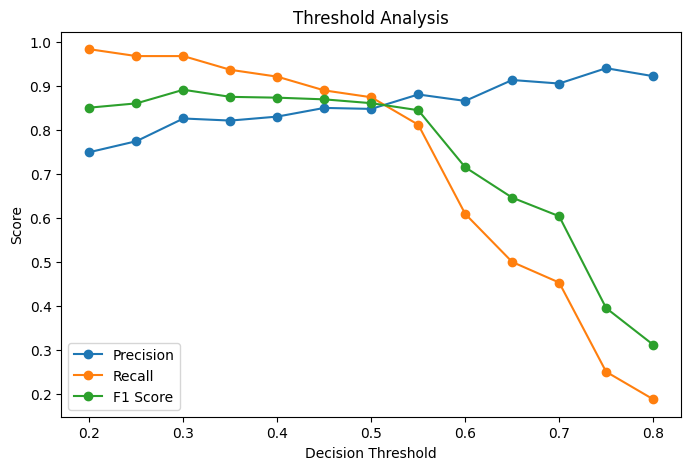

In [ ]:
#Visualization
plt.figure(figsize=(8,5))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Decision Threshold")
plt.ylabel("Score")

plt.title("Threshold Analysis")

plt.legend()

plt.show()

In [ ]:
#F1-Based Threshold
y_prob_val_rf = rf_model.predict_proba(X_val)[:, 1]
thresholds = np.arange(
    0.20,
    0.81,
    0.01
)

threshold_results = []

for threshold in thresholds:

    predictions = (
        y_prob_val_rf >= threshold
    ).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_val,
            predictions,
            zero_division=0
        ),
        "F1": f1_score(
            y_val,
            predictions,
            zero_division=0
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

In [ ]:
best_threshold = threshold_df.loc[
    threshold_df["F1"].idxmax(),
    "Threshold"
]

print("Suggested F1-based threshold:",
      best_threshold)

Suggested F1-based threshold: 0.37000000000000016


In [ ]:
#Final Test Evaluation Using Selected Threshold
y_prob_test_rf = rf_model.predict_proba(
    X_test
)[:, 1]

y_pred_threshold = (
    y_prob_test_rf >= best_threshold
).astype(int)
print("Final Model Performance")
print("----------------------------")

print("Threshold:", best_threshold)

print(
    "Precision:",
    precision_score(
        y_test,
        y_pred_threshold
    )
)

print(
    "Recall:",
    recall_score(
        y_test,
        y_pred_threshold
    )
)

print(
    "F1 Score:",
    f1_score(
        y_test,
        y_pred_threshold
    )
)

print(
    "ROC-AUC:",
    roc_auc_score(
        y_test,
        y_prob_test_rf
    )
)

Final Model Performance
----------------------------
Threshold: 0.37000000000000016
Precision: 0.8333333333333334
Recall: 0.9375
F1 Score: 0.8823529411764706
ROC-AUC: 0.8248922413793103


In [ ]:
#Feature Importance
preprocessor_fitted = rf_model.named_steps[
    "preprocessor"
]
feature_names = (
    preprocessor_fitted
    .get_feature_names_out()
)
importances = (
    rf_model
    .named_steps["classifier"]
    .feature_importances_
)

In [ ]:
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
4,num__Credit_History,0.262143
2,num__LoanAmount,0.167099
0,num__ApplicantIncome,0.165278
1,num__CoapplicantIncome,0.125785
3,num__Loan_Amount_Term,0.050316
12,cat__Property_Area_Semiurban,0.040835
10,cat__Education_Not Graduate,0.032037
8,cat__Dependents_2,0.029711
6,cat__Married_Yes,0.029181
7,cat__Dependents_1,0.023115


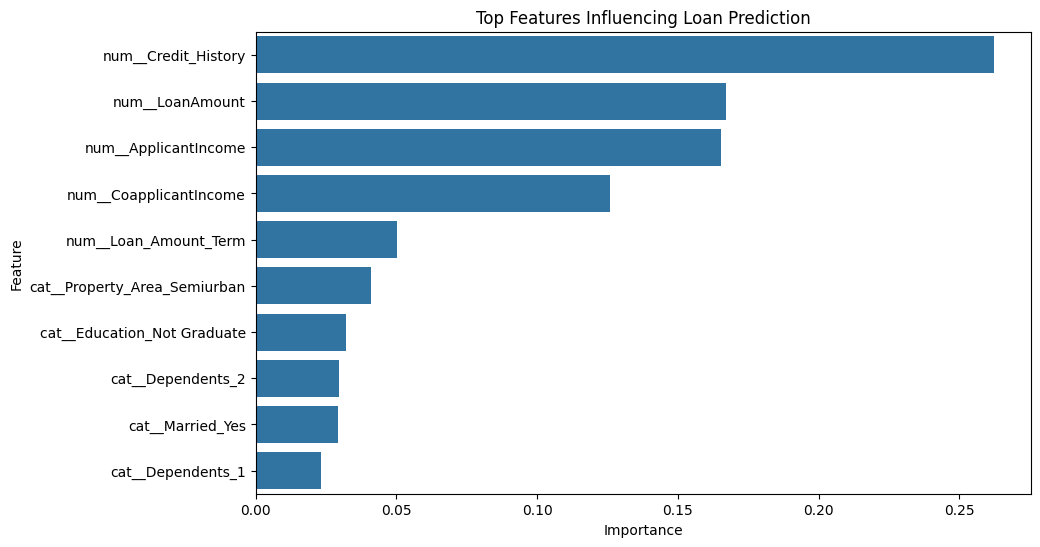

In [ ]:
#Visualization
top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top Features Influencing Loan Prediction")

plt.show()

**##Business-Oriented Interpretation**

**Credit History:-**
The model can use credit-history information as an important borrower characteristic. Applicants with different credit-history values may receive different predicted approval probabilities.

**Applicant Income:-**
Income can provide information about the applicant's ability to meet loan obligations.

**Loan Amount:-**
The requested loan amount can affect the model's predicted approval probability in combination with other borrower characteristics.

**Education and Employment:-**
Education and employment-related variables can provide additional information about the applicant profile.

**Property Area:-**
Property location can also contribute to differences in predictions depending on the patterns learned from the training data.


##**Precision** =True Positives / (True Positives + False Positives)

##**Recall** =True Positives / (True Positives + False Negatives)

##**F1** = 2 × (Precision × Recall)/ (Precision + Recall)

##**ROC-AUC** =ROC-AUC measures how well the model distinguishes between the two classes across different probability thresholds.


##**Model Trade-off discussion** = Logistic Regression provides a relatively simple and interpretable baseline model. Its coefficients can help explain the relationship between the input variables and predicted loan approval.Random Forest is a tree-based ensemble model capable of learning nonlinear relationships and interactions between borrower characteristics. However, its individual predictions are generally less straightforward to interpret than Logistic Regression.The final model should therefore be selected based on the observed precision, recall, F1-score, ROC-AUC, interpretability requirements, and the business cost of false positive and false negative predictions.



##**Deployment** **Threshold** **:-**   The default classification threshold of 0.50 was evaluated against alternative thresholds. A validation-based threshold was selected according to the desired balance between precision and recall. The selected threshold should be reviewed against the business cost of incorrect loan decisions before production deployment.